<a href="https://colab.research.google.com/github/meenakiet-cmyk/Team1/blob/main/Team1_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

          MAGNETIC FIELD ENERGY FORM (D8)

1. INPUT VALUES
-----------------------------------------------------------------
L1  = 4.000 H
L2  = 3.000 H
L3  = 2.500 H
M12 = 0.800 H
M13 = 0.500 H
M23 = 0.600 H

Currents:
i1 = 2.000 A
i2 = 1.500 A
i3 = 1.000 A

2. INDUCTANCE MATRIX L
-----------------------------------------------------------------
[[4.  0.8 0.5]
 [0.8 3.  0.6]
 [0.5 0.6 2.5]]

3. QUADRATIC FORM
-----------------------------------------------------------------
W = (1/2) i^T L i

Symbolic form:
      2                                 2                      2
2.0⋅i₁  + 0.8⋅i₁⋅i₂ + 0.5⋅i₁⋅i₃ + 1.5⋅i₂  + 0.6⋅i₂⋅i₃ + 1.25⋅i₃ 

4. STORED MAGNETIC ENERGY
-----------------------------------------------------------------
W = 16.925000 J

5. EIGENVALUES / PRINCIPAL INDUCTANCES
-----------------------------------------------------------------
Principal inductance 1 = 2.099368 H
Principal inductance 2 = 2.710878 H
Principal inductance 3 = 4.689754 H

6. EIGENVECTORS / PRINCIPAL MODE

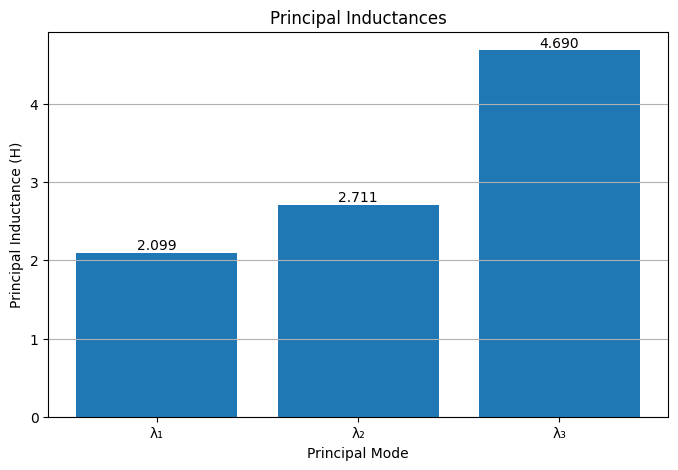

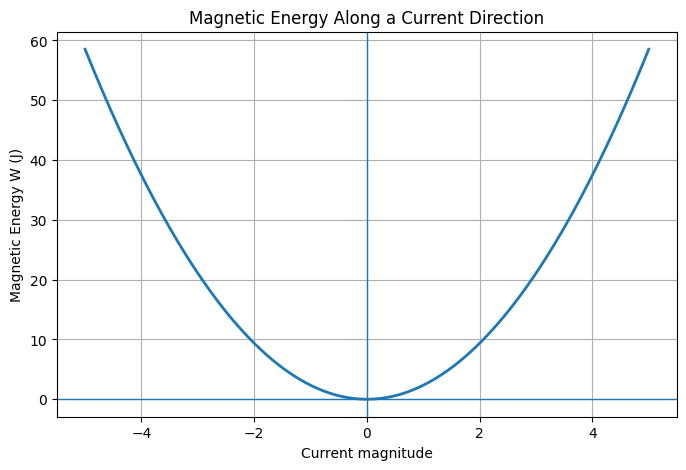

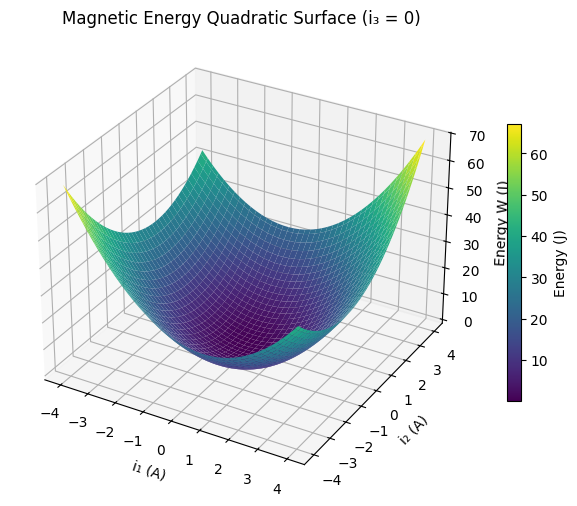


             BENCHMARK TEST DATASET

Benchmark Matrix:
[[5.  0.7 0.4]
 [0.7 4.  0.5]
 [0.4 0.5 3. ]]

Benchmark Current Vector:
[1.5 2.  1. ]

Benchmark Energy = 18.825000 J

Benchmark Principal Inductances:
λ1 = 2.787028 H
λ2 = 3.714004 H
λ3 = 5.498968 H

Benchmark Classification: Positive Definite

                    PROJECT SUMMARY

Mathematical Model:
    W = (1/2) i^T L i

Mathematical Concepts:
    • Quadratic form
    • Positive definiteness
    • Eigenvalues
    • Eigenvectors
    • Principal inductances

Physical Meaning:
    Positive definiteness means that every non-zero
    current state stores positive magnetic energy.

Real-World Applications:
    • Transformers
    • Motors
    • Coupled coils
    • Electrical engineering systems

Software Used:
    • Python
    • NumPy
    • SymPy
    • Matplotlib
    • Google Colab

                 END OF PROJECT


In [ ]:
# ============================================================
# MAGNETIC FIELD ENERGY FORM (D8)
# B.Tech Mathematics Mini Project
# ============================================================

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------------------
# 1. INPUT CONFIGURATION
# ------------------------------------------------------------
# Self-inductances of the three coils (Henry)
L1 = 4.0
L2 = 3.0
L3 = 2.5

# Mutual inductances between coils (Henry)
M12 = 0.8
M13 = 0.5
M23 = 0.6

# Currents through the three coils (Ampere)
i1 = 2.0
i2 = 1.5
i3 = 1.0

# Current vector
currents = np.array([i1, i2, i3], dtype=float)

# ------------------------------------------------------------
# 2. CONSTRUCT THE INDUCTANCE MATRIX
# ------------------------------------------------------------
# For three coupled coils:
#
#       [ L1   M12  M13 ]
# L  =  [ M12  L2   M23 ]
#       [ M13  M23  L3  ]
#
# The matrix is symmetric.

L = np.array([
    [L1,  M12, M13],
    [M12, L2,  M23],
    [M13, M23, L3]
], dtype=float)

# ------------------------------------------------------------
# 3. CALCULATE MAGNETIC ENERGY
# ------------------------------------------------------------
# Standard magnetic-energy formula:
#
#             W = 1/2 * i^T * L * i

energy = 0.5 * currents.T @ L @ currents

# ------------------------------------------------------------
# 4. SYMBOLIC QUADRATIC FORM
# ------------------------------------------------------------

x1, x2, x3 = sp.symbols("i1 i2 i3")

L_sym = sp.Matrix(L)
i_sym = sp.Matrix([x1, x2, x3])

W_sym = sp.expand(
    sp.Rational(1, 2) * (i_sym.T * L_sym * i_sym)[0]
)

# ------------------------------------------------------------
# 5. EIGENVALUES AND EIGENVECTORS
# ------------------------------------------------------------
# Since L is symmetric, eigvalsh/eigh gives real eigenvalues.

eigenvalues, eigenvectors = np.linalg.eigh(L)

# The eigenvalues are the principal inductances.
principal_inductances = eigenvalues

# ------------------------------------------------------------
# 6. CLASSIFY THE QUADRATIC FORM
# ------------------------------------------------------------

tolerance = 1e-10

if np.all(eigenvalues > tolerance):
    classification = "Positive Definite"

elif np.all(eigenvalues >= -tolerance):
    classification = "Positive Semidefinite"

elif np.all(eigenvalues < -tolerance):
    classification = "Negative Definite"

elif np.all(eigenvalues <= tolerance):
    classification = "Negative Semidefinite"

else:
    classification = "Indefinite"

# ------------------------------------------------------------
# 7. PRINCIPAL MINORS
# ------------------------------------------------------------
# Sylvester's criterion:
# A symmetric matrix is positive definite if all
# leading principal minors are positive.

D1 = np.linalg.det(L[:1, :1])
D2 = np.linalg.det(L[:2, :2])
D3 = np.linalg.det(L)

# ------------------------------------------------------------
# 8. PRINCIPAL COORDINATES
# ------------------------------------------------------------
# Transform the current vector into the eigenvector basis.

principal_currents = eigenvectors.T @ currents

# Energy contribution of each principal mode

mode_energy = 0.5 * eigenvalues * principal_currents**2

# ------------------------------------------------------------
# 9. DISPLAY RESULTS
# ------------------------------------------------------------

print("=" * 65)
print("          MAGNETIC FIELD ENERGY FORM (D8)")
print("=" * 65)

print("\n1. INPUT VALUES")
print("-" * 65)

print(f"L1  = {L1:.3f} H")
print(f"L2  = {L2:.3f} H")
print(f"L3  = {L3:.3f} H")

print(f"M12 = {M12:.3f} H")
print(f"M13 = {M13:.3f} H")
print(f"M23 = {M23:.3f} H")

print(f"\nCurrents:")
print(f"i1 = {i1:.3f} A")
print(f"i2 = {i2:.3f} A")
print(f"i3 = {i3:.3f} A")

print("\n2. INDUCTANCE MATRIX L")
print("-" * 65)
print(L)

print("\n3. QUADRATIC FORM")
print("-" * 65)
print("W = (1/2) i^T L i")

print("\nSymbolic form:")
sp.pprint(W_sym)

print("\n4. STORED MAGNETIC ENERGY")
print("-" * 65)
print(f"W = {energy:.6f} J")

print("\n5. EIGENVALUES / PRINCIPAL INDUCTANCES")
print("-" * 65)

for k, value in enumerate(eigenvalues, start=1):
    print(f"Principal inductance {k} = {value:.6f} H")

print("\n6. EIGENVECTORS / PRINCIPAL MODES")
print("-" * 65)

for k in range(3):
    print(f"Mode {k+1}:")
    print(eigenvectors[:, k])

print("\n7. PRINCIPAL MINORS")
print("-" * 65)

print(f"D1 = {D1:.6f}")
print(f"D2 = {D2:.6f}")
print(f"D3 = {D3:.6f}")

print("\n8. QUADRATIC FORM CLASSIFICATION")
print("-" * 65)
print(classification)

print("\n9. PHYSICAL INTERPRETATION")
print("-" * 65)

if classification == "Positive Definite":

    print("✓ The inductance matrix is positive definite.")
    print("✓ Energy is positive for every non-zero current vector.")
    print("✓ This is physically consistent with a passive magnetic system.")

elif classification == "Positive Semidefinite":

    print("✓ The inductance matrix is positive semidefinite.")
    print("✓ Energy is never negative.")
    print("⚠ Some non-zero current combinations may have zero energy.")

else:

    print("✗ The matrix is not positive semidefinite.")
    print("✗ It would allow negative values of the energy.")
    print("✗ Such parameters are not physically valid for a passive")
    print("  inductive energy-storage system.")

print("\n10. PRINCIPAL COORDINATES")
print("-" * 65)

for k, value in enumerate(principal_currents, start=1):
    print(f"q{k} = {value:.6f}")

print("\nEnergy contribution of each principal mode:")

for k, value in enumerate(mode_energy, start=1):
    print(f"Mode {k}: {value:.6f} J")

print(f"\nSum of mode energies = {np.sum(mode_energy):.6f} J")
print(f"Original energy      = {energy:.6f} J")

# ============================================================
# 11. GRAPH 1 — PRINCIPAL INDUCTANCES
# ============================================================

plt.figure(figsize=(8, 5))

labels = ["λ₁", "λ₂", "λ₃"]

bars = plt.bar(labels, eigenvalues)

plt.xlabel("Principal Mode")
plt.ylabel("Principal Inductance (H)")
plt.title("Principal Inductances")

for bar, value in zip(bars, eigenvalues):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y")
plt.show()

# ============================================================
# 12. GRAPH 2 — ENERGY ALONG A CURRENT DIRECTION
# ============================================================

direction = np.array([1.0, 0.7, 0.4])

direction = direction / np.linalg.norm(direction)

magnitudes = np.linspace(-5, 5, 200)

energies = []

for a in magnitudes:

    current_vector = a * direction

    W = 0.5 * current_vector.T @ L @ current_vector

    energies.append(W)

plt.figure(figsize=(8, 5))

plt.plot(magnitudes, energies, linewidth=2)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Current magnitude")
plt.ylabel("Magnetic Energy W (J)")
plt.title("Magnetic Energy Along a Current Direction")

plt.grid(True)
plt.show()

# ============================================================
# 13. GRAPH 3 — 3D ENERGY SURFACE
# ============================================================

i1_values = np.linspace(-4, 4, 80)
i2_values = np.linspace(-4, 4, 80)

I1, I2 = np.meshgrid(i1_values, i2_values)

# Fix i3 = 0

W_surface = 0.5 * (
    L[0, 0] * I1**2
    + L[1, 1] * I2**2
    + 2 * L[0, 1] * I1 * I2
)

fig = plt.figure(figsize=(9, 6))

ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    I1,
    I2,
    W_surface,
    cmap="viridis"
)

ax.set_xlabel("i₁ (A)")
ax.set_ylabel("i₂ (A)")
ax.set_zlabel("Energy W (J)")

ax.set_title(
    "Magnetic Energy Quadratic Surface (i₃ = 0)"
)

fig.colorbar(
    surface,
    ax=ax,
    shrink=0.6,
    label="Energy (J)"
)

plt.show()

# ============================================================
# 14. BENCHMARK TEST DATASET
# ============================================================

print("\n" + "=" * 65)
print("             BENCHMARK TEST DATASET")
print("=" * 65)

benchmark = {
    "L1": 5.0,
    "L2": 4.0,
    "L3": 3.0,
    "M12": 0.7,
    "M13": 0.4,
    "M23": 0.5,
    "i1": 1.5,
    "i2": 2.0,
    "i3": 1.0
}

Lb = np.array([
    [benchmark["L1"],  benchmark["M12"], benchmark["M13"]],
    [benchmark["M12"], benchmark["L2"],  benchmark["M23"]],
    [benchmark["M13"], benchmark["M23"], benchmark["L3"]]
], dtype=float)

ib = np.array([
    benchmark["i1"],
    benchmark["i2"],
    benchmark["i3"]
], dtype=float)

benchmark_energy = 0.5 * ib.T @ Lb @ ib

benchmark_eigenvalues = np.linalg.eigvalsh(Lb)

print("\nBenchmark Matrix:")
print(Lb)

print("\nBenchmark Current Vector:")
print(ib)

print(f"\nBenchmark Energy = {benchmark_energy:.6f} J")

print("\nBenchmark Principal Inductances:")

for k, value in enumerate(benchmark_eigenvalues, start=1):
    print(f"λ{k} = {value:.6f} H")

if np.all(benchmark_eigenvalues > 0):

    print("\nBenchmark Classification: Positive Definite")

elif np.all(benchmark_eigenvalues >= 0):

    print("\nBenchmark Classification: Positive Semidefinite")

else:

    print("\nBenchmark Classification: Not Positive Semidefinite")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 65)
print("                    PROJECT SUMMARY")
print("=" * 65)

print("""
Mathematical Model:
    W = (1/2) i^T L i

Mathematical Concepts:
    • Quadratic form
    • Positive definiteness
    • Eigenvalues
    • Eigenvectors
    • Principal inductances

Physical Meaning:
    Positive definiteness means that every non-zero
    current state stores positive magnetic energy.

Real-World Applications:
    • Transformers
    • Motors
    • Coupled coils
    • Electrical engineering systems

Software Used:
    • Python
    • NumPy
    • SymPy
    • Matplotlib
    • Google Colab
""")

print("=" * 65)
print("                 END OF PROJECT")
print("=" * 65)